In [3]:
# step 1: import libraries
# importing pandas to work with the dataset
import pandas as pd

In [4]:
# step 2: load the dataset
# # reading in the csv file containing 50,000 studentd records on GenAI usages and academic outcomes.
data=pd.read_csv("ai_student_impact_dataset (1).csv")

In [5]:
# step 3: initial data check
# checking summary statistics(mean,min,max,etc.) to understand the scale and range of each numeric column.
data.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [6]:
# step 4: checking data types and missing values
# confirming column types are correct and checking for any missing data before analysis
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [7]:
# preview the first few rows to see what the raw data actually looks like
data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [8]:
# confirming the dataset size: number of rows, columns, and column names.
data.shape
data.columns
len(data)


50000

In [11]:
# step 5: create a GPA Change column
# calculating each student's GPA change(post-semester minus pre-semester) to measure academic impact.
data["GPA_Change"]=data["Post_Semester_GPA"] - data["Pre_Semester_GPA"]
data["GPA_Change"].mean()

np.float64(0.20319708000000003)

In [12]:
# step 6: Group students by weekly AI Usage
# Splitting students into four usage bands(Very Low, Low, Moderate, High) to compare outcomes across usage levels.
data["AI_usage_group"]= pd.cut(data["Weekly_GenAI_Hours"],
                               bins=[-1, 2, 10,20,100],
                               labels=["very Low", "Low", "Moderate", "High"])
data.groupby("AI_usage_group",observed=True)["GPA_Change"].mean()

AI_usage_group
very Low    0.187749
Low         0.214285
Moderate    0.216362
High        0.156227
Name: GPA_Change, dtype: float64

In [14]:
# step 7: Explore Burnout Risk
# checking how anxiety levels relate to burnout risk categories.
data.groupby("AI_usage_group", observed=True)["Anxiety_Level_During_Exams"].mean()

AI_usage_group
very Low    3.809404
Low         3.976275
Moderate    4.786001
High        5.621055
Name: Anxiety_Level_During_Exams, dtype: float64

In [15]:
# step 8: Burnout Risk by AI Usage
# Building a table showing what proportion of students in each usage group fall into High/Low/Medium burnout risk.
burnout_table=pd.crosstab(data["AI_usage_group"],data["Burnout_Risk_Level"], normalize="index")
burnout_table

Burnout_Risk_Level,High,Low,Medium
AI_usage_group,,,
very Low,0.089013,0.498603,0.412384
Low,0.154880,0.383725,0.461394
Moderate,0.399844,0.163261,0.436895
High,0.743108,0.024970,0.231922


In [22]:
# still on building a table by hiding index to give a cleaner look
burnout_table.style.hide(axis="index")


AI_usage_group,High Burnout,Low Burnout,Medium Burnout
very Low,0.089013,0.498603,0.412384
Low,0.154880,0.383725,0.461394
Moderate,0.399844,0.163261,0.436895
High,0.743108,0.024970,0.231922


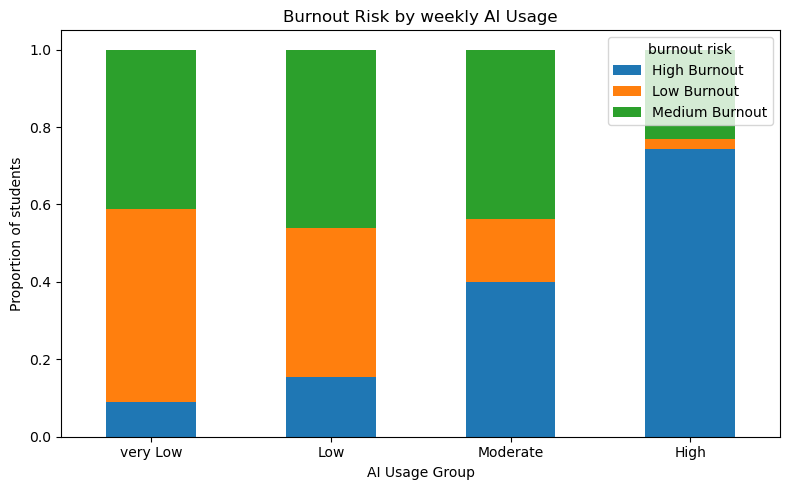

In [30]:
# step 9:  importing matplotlib for visualization Visualize the findings
# charting burnout risk  by AI usage group to see the patterns clearly.
import matplotlib.pyplot as plt
chart_data=burnout_table.set_index("AI_usage_group")
chart_data=chart_data.drop(columns="index",errors="ignore")
chart_data.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Burnout Risk by weekly AI Usage")
plt.ylabel("Proportion of students")
plt.xlabel("AI Usage Group")
plt.xticks(rotation=0)
plt.legend(title="burnout risk")
plt.tight_layout()
plt.savefig("burnout_by_ai_usage.png")
plt.show()

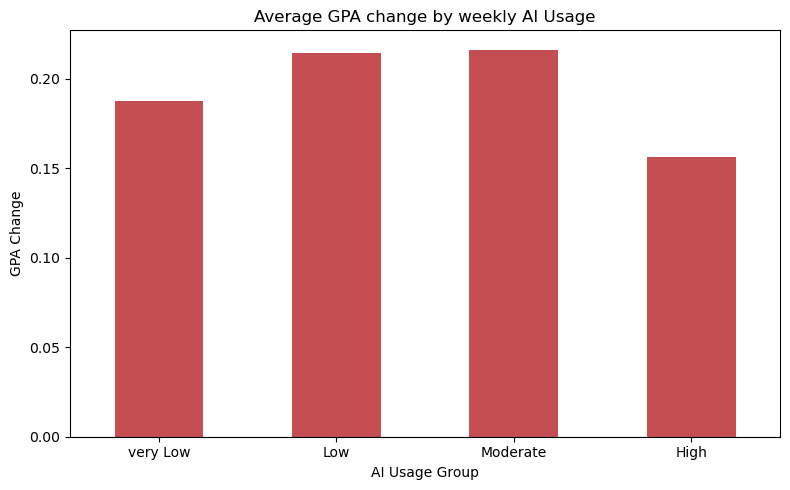

In [44]:
# Visualize the findings
# charting GPA change  by AI usage group to see the patterns clearly.
gpa_by_group=data.groupby("AI_usage_group", observed=True)["GPA_Change"].mean()
gpa_by_group.plot(kind="bar", stacked=True, figsize=(8,5), color="#c44e52")
plt.title("Average GPA change by weekly AI Usage")
plt.ylabel("GPA Change")
plt.xlabel("AI Usage Group")
plt.xticks(rotation=0)
plt.axhline(0,color="gray",linewidth=0.8)
plt.tight_layout()
plt.savefig("GPA_Change_by_ai_usage.png")
plt.show()

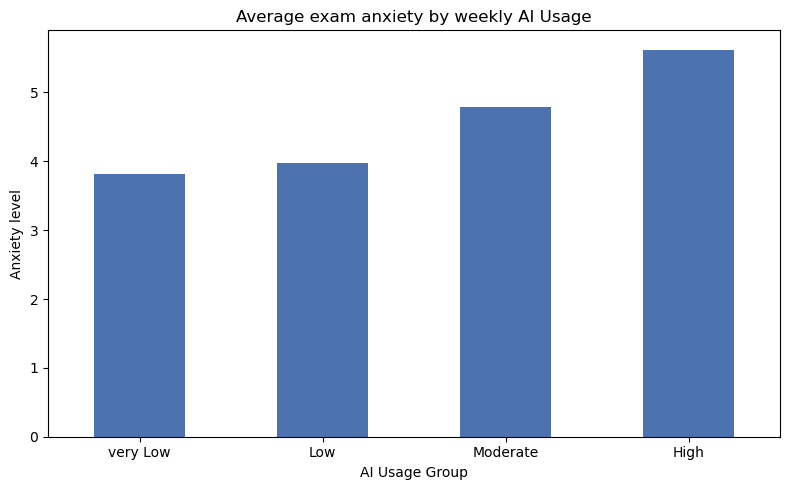

In [45]:
# Visualize the findings
# charting average exam anxiety  by AI usage group to see the patterns clearly.
anxiety_by_group=data.groupby("AI_usage_group", observed=True)["Anxiety_Level_During_Exams"].mean()
anxiety_by_group.plot(kind="bar", stacked=True, figsize=(8,5), color="#4c72b0")
plt.title("Average exam anxiety by weekly AI Usage")
plt.ylabel("Anxiety level")
plt.xlabel("AI Usage Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Anxiety_by_ai_usage.png")
plt.show()